# Bài tập 4 – Gom cụm (Clustering)

**Dữ liệu**: Hotel Booking Demand 
---


## [01] Load dữ liệu đã xử lý từ Bài 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering
sns.set(style='whitegrid', palette='muted')

DATA_PATH = '../data/processed/hotel_bookings_processed.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f"Kích thước dữ liệu gốc: {df_raw.shape}")
df_raw.head(5)
print(df_raw.shape)


Kích thước dữ liệu gốc: (117398, 43)
(117398, 43)


## [02] Kiểm tra dữ liệu đầu vào

In [3]:
print("=== Kiểu dữ liệu ===")
print(df_raw.dtypes)
print("\n=== Giá trị null ===")
print(df_raw.isnull().sum())
print("\n=== Thống kê mô tả ===")
df_raw.describe().round(2)


=== Kiểu dữ liệu ===
is_canceled                         int64
lead_time                         float64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
country                            object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
agent                             float64
company                           float64
days_in_waiting_list                int64
customer_type                      object
adr          

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_stay,total_people,is_family
count,117398.00,117398.00,117398.00,117398.00,117398.00,117398.00,117398.00,117398.00,117398.0,117398.00,...,117398.00,117398.00,117398.00,117398.00,117398.00,117398.00,117398.00,117398.00,117398.00,117398.00
mean,0.37,0.00,2016.16,27.14,15.80,0.94,2.52,1.86,0.1,0.01,...,0.22,75.19,10.55,2.34,-0.00,0.06,0.57,-0.00,1.97,0.08
std,0.48,1.00,0.71,13.58,8.78,0.99,1.89,0.48,0.4,0.10,...,0.63,107.24,53.55,17.68,1.00,0.25,0.79,1.00,0.65,0.27
min,0.00,-0.98,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.00,-2.21,0.00,0.00,-0.97,1.00,0.00
25%,0.00,-0.81,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,...,0.00,7.00,0.00,0.00,-0.71,0.00,0.00,-0.58,2.00,0.00
50%,0.00,-0.32,2016.00,27.00,16.00,1.00,2.00,2.00,0.0,0.00,...,0.00,9.00,0.00,0.00,-0.18,0.00,0.00,-0.18,2.00,0.00
75%,1.00,0.53,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,...,0.00,154.00,0.00,0.00,0.48,0.00,1.00,0.21,2.00,0.00
max,1.00,5.65,2017.00,53.00,31.00,19.00,50.00,4.00,10.0,10.00,...,18.00,535.00,543.00,391.00,8.70,8.00,5.00,25.91,12.00,1.00


## [03] Feature Selection

Chọn các đặc trưng phù hợp cho bài toán gom cụm hành vi khách đặt phòng.  
Loại bỏ: nhãn cụm từ bài trước  `is_canceled` (kết quả không phải đặc trưng hành vi).

**Đặc trưng số**: `lead_time`, `stays_in_weekend_nights`, `stays_in_week_nights`, `adults`, `children`, `babies`, `adr`, `required_car_parking_spaces`, `total_of_special_requests`  
**Đặc trưng hạng mục**: `hotel`, `market_segment`, `distribution_channel`, `customer_type`


In [4]:
# Bỏ các cột không phải đặc trưng hành vi
DROP_COLS = [
    'is_canceled',
    'country',
    'agent',
    'company',
    'reserved_room_type',
    'assigned_room_type'
]

df = df_raw.drop(columns=[c for c in DROP_COLS if c in df_raw.columns]).copy()

# Các biến số sử dụng trực tiếp
NUM_COLS = [
    'lead_time',
    'arrival_date_year',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'total_stay',
    'total_people',
    'is_family'
]

# Các biến categorical cần encoding ở Bước 4
CAT_COLS = [
    'arrival_date_month',
    'distribution_channel',
    'customer_type'
]


# Các biến categorical đã được One-Hot Encoding từ Bài 1
OHE_COLS = [
    c for c in df.columns
    if c.startswith(('hotel_', 'meal_', 'market_segment_', 'deposit_type_'))
]

print("Số biến số:", len(NUM_COLS))
print("Số biến categorical cần encoding:", len(CAT_COLS))
print("Số biến đã One-Hot:", len(OHE_COLS))
print("Kích thước dữ liệu:", df.shape)

Số biến số: 20
Số biến categorical cần encoding: 3
Số biến đã One-Hot: 14
Kích thước dữ liệu: (117398, 37)


## [04] Kiểm tra và xử lý biến categorical
Các biến categorical cần được chuyển sang dạng số để các thuật toán gom cụm dựa trên khoảng cách như K-Means và Hierarchical Clustering có thể xử lý.

Trong dữ liệu đã được tiền xử lý từ Bài 1, một số biến categorical đã được One-Hot Encoding. Các biến categorical còn lại được mã hóa phù hợp trước khi đưa vào bước chuẩn hóa.

Sau bước này, tất cả các thuộc tính sử dụng cho mô hình đều ở dạng số → có thể chuẩn hóa và đưa vào thuật toán gom cụm.


In [5]:
# [04] Đưa các biến categorical về dạng nhị phân 0/1
df_enc = df.copy()

#Xử lý các categorical arrival_date_month
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

df_enc['arrival_date_month'] = df_enc['arrival_date_month'].map(month_map)

# One-Hot Encoding cho categorical còn lại
df_enc = pd.get_dummies(
    df_enc,
    columns=['distribution_channel', 'customer_type'],
    dtype=int
)

print("Các biến object còn lại:")
print(df_enc.select_dtypes(include='object').columns.tolist())
print("df_enc:", df_enc.shape)
print("Số cột:", len(df_enc.columns))

Các biến object còn lại:
[]
df_enc: (117398, 44)
Số cột: 44


## [05] Scaling (Chuẩn hoá) 🔴

**Tại sao bắt buộc?**  
K-Means và Agglomerative dựa trên **khoảng cách Euclidean**.  
Nếu không chuẩn hoá, đặc trưng có phạm vi lớn (ví dụ `lead_time` 0–400, `adr` 0–5000)  
sẽ áp đảo đặc trưng có phạm vi nhỏ (ví dụ `babies` 0–2), làm sai lệch phân cụm.

**Phương pháp**: `StandardScaler` → mỗi đặc trưng có mean=0, std=1.


In [6]:
# [05] Scaling
scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_enc),
    columns=df_enc.columns,
    index=df_enc.index
)

# Kết quả sau scaling
print("KẾT QUẢ SAU SCALING:")
display(
    df_scaled.describe()
    .loc[['mean', 'std']]
    .round(2)
)

KẾT QUẢ SAU SCALING:


,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,deposit_type_Refundable,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
mean,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,...,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## [06] Tạo X cuối cùng
 Gom phần dữ liệu đó thành ma trận X, để đưa trực tiếp vào các thuật toán clustering

In [7]:
# Ma trận đặc trưng cuối cùng
X = df_scaled.values

print(f"X.shape = {X.shape} → {X.shape[0]} mẫu, {X.shape[1]} đặc trưng")

display(df_scaled.head())

X.shape = (117398, 44) → 117398 mẫu, 44 đặc trưng


,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,deposit_type_Refundable,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,-0.917518,-1.641997,0.147261,-0.010034,-1.685308,-0.94118,-0.804467,-1.789470,-0.261504,-0.08099,...,-0.037173,-0.241765,2.736203,-0.040156,-2.173463,-0.006526,-0.189074,-0.068167,0.576216,-0.515771
1,-0.861398,-1.641997,0.147261,-0.010034,-1.685308,-0.94118,-0.804467,-1.789470,-0.261504,-0.08099,...,-0.037173,4.136253,-0.365470,-0.040156,-2.173463,-0.006526,-0.189074,-0.068167,0.576216,-0.515771
2,-0.852045,-1.641997,0.147261,-0.010034,-1.685308,-0.94118,-0.275361,0.288598,-0.261504,-0.08099,...,-0.037173,-0.241765,-0.365470,-0.040156,0.460095,-0.006526,-0.189074,-0.068167,0.576216,-0.515771
3,-0.852045,-1.641997,0.147261,-0.010034,-1.685308,-0.94118,-0.275361,0.288598,-0.261504,-0.08099,...,-0.037173,-0.241765,-0.365470,-0.040156,0.460095,-0.006526,-0.189074,-0.068167,0.576216,-0.515771
4,-0.982992,-1.641997,0.147261,-0.010034,-1.685308,-0.94118,-0.275361,0.288598,-0.261504,-0.08099,...,-0.037173,-0.241765,2.736203,-0.040156,-2.173463,-0.006526,-0.189074,-0.068167,0.576216,-0.515771


## [07] Thuật toán K-Means

**Giả định**:
- Các cụm có dạng hình cầu, kích thước tương đương
- Khoảng cách Euclidean là thước đo phù hợp
- Số cụm K phải được chỉ định trước

**Cơ chế**: Lặp gán điểm vào centroid gần nhất → cập nhật centroid → hội tụ khi centroid không đổi.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

K_RANGE = range(2, 11)

inertias = []
sil_scores = []

# Chọn ngẫu nhiên 15.000 dòng để tính Silhouette
np.random.seed(42)
sample_idx = np.random.choice(
    X.shape[0],
    size=15000,
    replace=False
)

X_sample = X[sample_idx]

for k in K_RANGE:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X)

    inertias.append(km.inertia_)

    # Chỉ tính Silhouette trên 10.000 dòng
    sil = silhouette_score(
        X_sample,
        km.labels_[sample_idx]
    )

    sil_scores.append(sil)

    print(f"K={k} hoàn thành")

print("\nk | Inertia       | Silhouette")
print("-" * 35)

for k, ine, sil in zip(K_RANGE, inertias, sil_scores):
    print(f"{k:2d} | {ine:12.1f} | {sil:.4f}")


K=2 hoàn thành
K=3 hoàn thành
K=4 hoàn thành
K=5 hoàn thành
K=6 hoàn thành
K=7 hoàn thành
K=8 hoàn thành
K=9 hoàn thành
K=10 hoàn thành

k | Inertia       | Silhouette
-----------------------------------
 2 |    4792379.7 | 0.2226
 3 |    4496358.7 | 0.1293
 4 |    4225950.3 | 0.1410
 5 |    4007529.0 | 0.1449
 6 |    3846608.1 | 0.1558
 7 |    3731055.4 | 0.1309
 8 |    3598955.9 | 0.1833
 9 |    3443931.9 | 0.1633
10 |    3363089.4 | 0.1160


## [08] Elbow + Silhouette → Chọn K 🔴

**Elbow Method**: Tìm điểm "khuỷu tay" – nơi Inertia giảm đột ngột chậm lại.  
**Silhouette Score**: Đo mức độ điểm thuộc cụm của nó so với cụm kế cận (1 = tốt, -1 = xấu).  
→ Chọn K có silhouette cao nhất hoặc thoả điểm elbow.


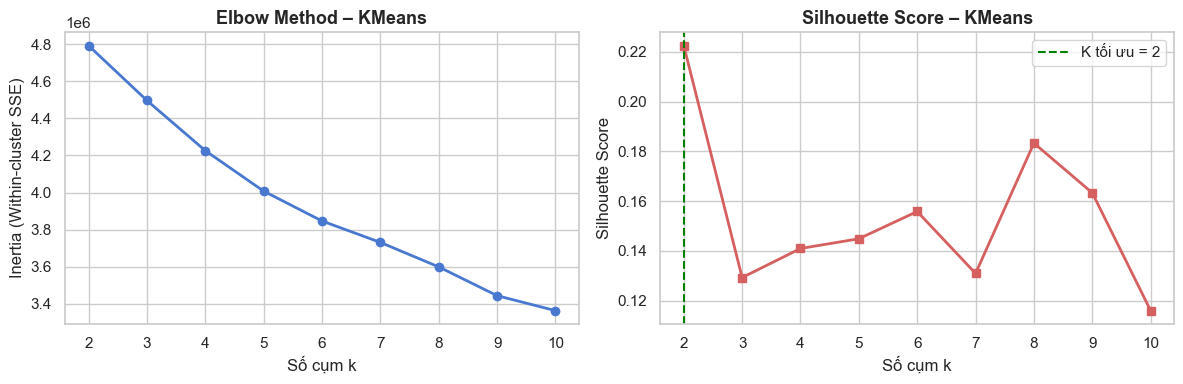


→ Chọn K = 2 (Silhouette = 0.2226)
KMeans k=2: Silhouette=0.2226, Davies-Bouldin=2.5680


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# =========================
# Elbow
# =========================
axes[0].plot(
    list(K_RANGE),
    inertias,
    'bo-',
    linewidth=2,
    markersize=6
)

axes[0].set_title(
    'Elbow Method – KMeans',
    fontsize=13,
    fontweight='bold'
)
axes[0].set_xlabel('Số cụm k')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_xticks(list(K_RANGE))


# =========================
# Silhouette
# =========================
axes[1].plot(
    list(K_RANGE),
    sil_scores,
    'rs-',
    linewidth=2,
    markersize=6
)

best_k = list(K_RANGE)[int(np.argmax(sil_scores))]

axes[1].axvline(
    x=best_k,
    color='green',
    linestyle='--',
    label=f'K tối ưu = {best_k}'
)

axes[1].set_title(
    'Silhouette Score – KMeans',
    fontsize=13,
    fontweight='bold'
)
axes[1].set_xlabel('Số cụm k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.tight_layout()

plt.savefig(
    'elbow_silhouette.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    f"\n→ Chọn K = {best_k} "
    f"(Silhouette = {max(sil_scores):.4f})"
)


# =========================
# Fit KMeans với K tối ưu
# =========================
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

km_labels = kmeans.fit_predict(X)


# =========================
# Đánh giá trên sample
# =========================
sil_km = silhouette_score(
    X_sample,
    km_labels[sample_idx]
)

db_km = davies_bouldin_score(
    X_sample,
    km_labels[sample_idx]
)

print(
    f"KMeans k={best_k}: "
    f"Silhouette={sil_km:.4f}, "
    f"Davies-Bouldin={db_km:.4f}"
)


## [09] Thuật toán DBSCAN

**Giả định**:
Hai tham số chính của DBSCAN:

- `eps`: bán kính lân cận của một điểm.
- `min_samples`: số điểm tối thiểu trong vùng lân cận `eps` để xác định một điểm là điểm lõi (core point).

**Cơ chế**:
DBSCAN phân loại các điểm thành:
- Core point: có ít nhất `min_samples` điểm trong bán kính `eps`.
- Border point: không phải core point nhưng nằm trong vùng lân cận của core point.
- Noise point: không thuộc vùng của các điểm lõi.


DBSCAN không yêu cầu xác định trước số cụm và có khả năng phát hiện
các điểm nhiễu.

Do DBSCAN sử dụng khoảng cách Euclidean, dữ liệu được chuẩn hóa trước
khi phân cụm để hạn chế ảnh hưởng của sự khác biệt về thang đo giữa
các đặc trưng.

In [10]:
#chọn min_samples
D = X.shape[1]
min_pts = 2 * D

print(f"Số đặc trưng D = {D}")
print(f"min_samples = {min_pts}")

Số đặc trưng D = 44
min_samples = 88


Với dữ liệu sau tiền xử lý có 44 đặc trưng, chọn ban đầu
`min_samples = 2 × D = 88` theo quy tắc kinh nghiệm.

Giá trị này được giữ cố định trong quá trình khảo sát và lựa chọn
`eps` ở các bước tiếp theo.

 9.1. Xác định vùng `eps` bằng K-distance Graph

Để lựa chọn `eps`, sử dụng K-distance Graph. Với mỗi điểm dữ liệu,
tính khoảng cách đến láng giềng thứ `min_samples`, sau đó sắp xếp
các khoảng cách theo thứ tự tăng dần.

Vùng mà đường cong bắt đầu tăng mạnh được xem là vùng giá trị
`eps` ứng viên.

Do dữ liệu có 117.398 dòng, sử dụng một mẫu ngẫu nhiên 15.000 dòng
để giảm chi phí tính toán khi xây dựng K-distance Graph.

Số đặc trưng D = 44
min_samples = 88

Các percentile của khoảng cách:
90% percentile: 5.8163
92% percentile: 6.2158
94% percentile: 6.7081
95% percentile: 7.0609
96% percentile: 7.6093
97% percentile: 8.7735
98% percentile: 9.8525
99% percentile: 15.0130
99.5% percentile: 17.3198
99.9% percentile: 30.5980


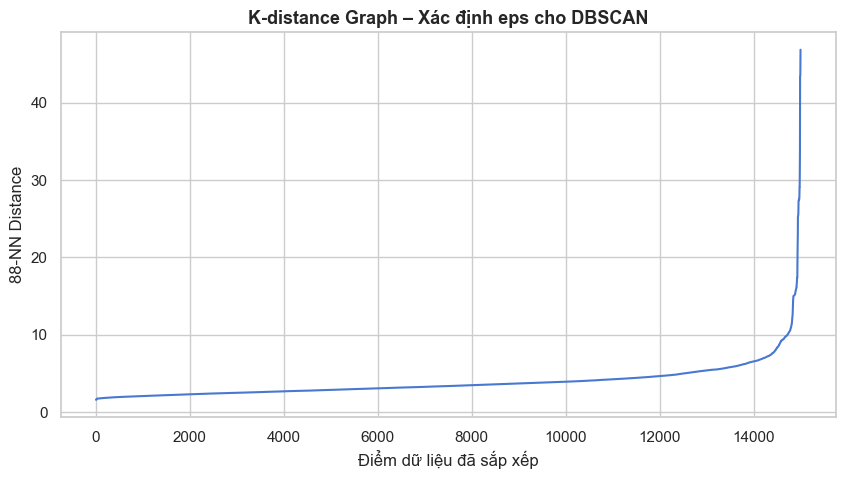

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

sample_idx = np.random.choice(
    X.shape[0],
    size=15000,
    replace=False
)

X_sample = X[sample_idx]

# Tính min_samples
# Quy tắc kinh nghiệm: min_samples = 2 × D
min_pts = X.shape[1] * 2

print(f"Số đặc trưng D = {X.shape[1]}")
print(f"min_samples = {min_pts}")

# Tìm k-distance trên X_sample = 15.000 mẫu
neighbors = NearestNeighbors(
    n_neighbors=min_pts,
    n_jobs=-1
)

neighbors_fit = neighbors.fit(X_sample)

distances, indices = neighbors_fit.kneighbors(X_sample)

# Lấy khoảng cách đến hàng xóm thứ min_samples
distances = np.sort(
    distances[:, min_pts - 1],
    axis=0
)

# ==============================
# XEM CÁC PERCENTILE
# ==============================
print("\nCác percentile của khoảng cách:")

for p in [90, 92, 94, 95, 96, 97, 98, 99, 99.5, 99.9]:
    print(
        f"{p}% percentile: "
        f"{np.percentile(distances, p):.4f}"
    )

# ==============================
# VẼ K-DISTANCE GRAPH
# ==============================
plt.figure(figsize=(10, 5))

plt.plot(distances)

plt.title(
    'K-distance Graph – Xác định eps cho DBSCAN',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Điểm dữ liệu đã sắp xếp')
plt.ylabel(f'{min_pts}-NN Distance')

plt.grid(True)
plt.show()

### 9.3. Nhận xét

Kết quả cho thấy dữ liệu có 44 đặc trưng, do đó `min_samples` được
khởi tạo bằng `2 × D = 88` theo quy tắc kinh nghiệm.

Từ K-distance Graph và các percentile của khoảng cách, khoảng cách
bắt đầu tăng rõ rệt khi `eps` tiến đến vùng khoảng 7–10. Cụ thể,
giá trị tại percentile 95% là 7.0609, 97% là 8.7735 và 98% là 9.8525.
Sau đó khoảng cách tăng mạnh hơn, đạt 15.0130 tại percentile 99%.

Do đó, các giá trị `eps` trong vùng khoảng 7–10 được xem là các giá trị
ứng viên để tiếp tục thử nghiệm.

Ở bước này chưa xác định `eps` tối ưu. Các giá trị `eps` ứng viên sẽ
được chạy và đánh giá ở bước [10] dựa trên số cụm, tỷ lệ điểm nhiễu,
Silhouette Score và Davies-Bouldin Index.

## [10] Thử nghiệm các giá trị `eps` – DBSCAN

Từ K-distance Graph ở bước [09], vùng `eps ≈ 7–10` được xem là
vùng giá trị ứng viên.

Thay vì chọn một giá trị `eps` duy nhất chỉ dựa trên đồ thị,
tiến hành thử nghiệm các giá trị:

`eps = 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0`

Trong quá trình thử nghiệm, giữ cố định `min_samples = 88` để
đánh giá riêng ảnh hưởng của `eps`.

Mỗi cấu hình được ghi nhận:
- Số cụm được tạo ra.
- Số lượng điểm nhiễu (noise).
- Tỷ lệ điểm nhiễu.

Các kết quả này sẽ được sử dụng ở bước tiếp theo để đánh giá
chất lượng phân cụm bằng Silhouette Score và Davies-Bouldin Index.

In [12]:
from sklearn.cluster import DBSCAN
import numpy as np

EPS_RANGE = [7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]

print(f"Kích thước dữ liệu: {X_sample.shape}")
print(f"min_samples = {min_pts}")

results_dbscan = []

for eps in EPS_RANGE:
    print(f"\nĐang chạy DBSCAN với eps = {eps}...")

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_pts,
        metric='euclidean',
        n_jobs=-1
    )

    labels = dbscan.fit_predict(X_sample)

    # Số cụm, không tính noise (-1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Số điểm noise
    n_noise = np.sum(labels == -1)

    # Tỷ lệ noise
    noise_ratio = n_noise / len(labels) * 100

    results_dbscan.append({
        'eps': eps,
        'min_samples': min_pts,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio
    })

    print(f"Số cụm: {n_clusters}")
    print(f"Noise: {n_noise}")
    print(f"Tỷ lệ noise: {noise_ratio:.2f}%")

Kích thước dữ liệu: (15000, 44)
min_samples = 88

Đang chạy DBSCAN với eps = 7.0...
Số cụm: 2
Noise: 419
Tỷ lệ noise: 2.79%

Đang chạy DBSCAN với eps = 7.5...
Số cụm: 2
Noise: 391
Tỷ lệ noise: 2.61%

Đang chạy DBSCAN với eps = 8.0...
Số cụm: 3
Noise: 282
Tỷ lệ noise: 1.88%

Đang chạy DBSCAN với eps = 8.5...
Số cụm: 3
Noise: 269
Tỷ lệ noise: 1.79%

Đang chạy DBSCAN với eps = 9.0...
Số cụm: 3
Noise: 258
Tỷ lệ noise: 1.72%

Đang chạy DBSCAN với eps = 9.5...
Số cụm: 4
Noise: 161
Tỷ lệ noise: 1.07%

Đang chạy DBSCAN với eps = 10.0...
Số cụm: 4
Noise: 159
Tỷ lệ noise: 1.06%


Ket Qua

In [13]:
df_dbscan_results = pd.DataFrame(results_dbscan)

display(
    df_dbscan_results[
        ['eps', 'min_samples', 'n_clusters', 'n_noise', 'noise_ratio']
    ]
)

,eps,min_samples,n_clusters,n_noise,noise_ratio
0,7.0,88,2,419,2.793333
1,7.5,88,2,391,2.606667
2,8.0,88,3,282,1.880000
3,8.5,88,3,269,1.793333
4,9.0,88,3,258,1.720000
5,9.5,88,4,161,1.073333
6,10.0,88,4,159,1.060000


## [11] Nhận xét kết quả thử nghiệm DBSCAN

Khi tăng `eps` từ 7.0 lên 10.0, số cụm tăng từ 2 lên 4,
trong khi tỷ lệ điểm nhiễu giảm từ 2.79% xuống 1.06%.

Kết quả cho thấy `eps` có ảnh hưởng trực tiếp đến số lượng cụm
và số điểm được xem là nhiễu. Các giá trị `eps` từ 8.0 đến 10.0
tạo ra từ 3 đến 4 cụm và có tỷ lệ nhiễu thấp hơn.

Chưa lựa chọn `eps` chỉ dựa trên tỷ lệ noise. Các cấu hình phù hợp
sẽ được đánh giá tiếp bằng Silhouette Score và Davies-Bouldin Index.

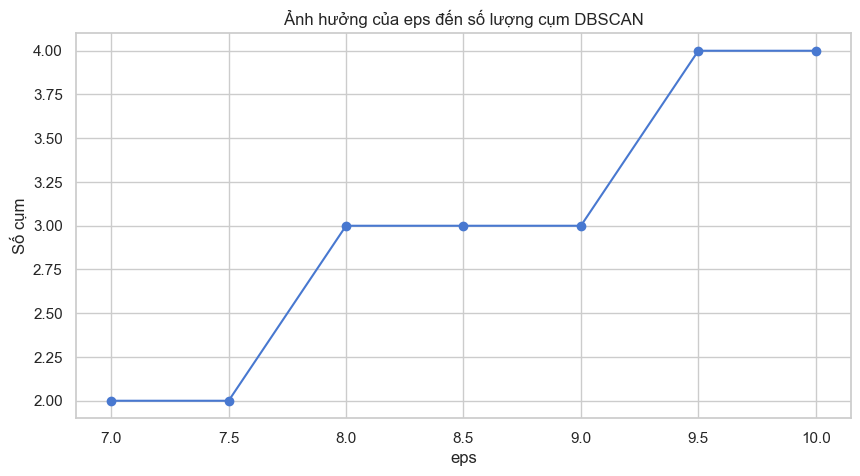

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    df_dbscan_results['eps'],
    df_dbscan_results['n_clusters'],
    marker='o'
)

plt.xlabel('eps')
plt.ylabel('Số cụm')
plt.title('Ảnh hưởng của eps đến số lượng cụm DBSCAN')
plt.grid(True)
plt.show()

## [12] Đánh giá: Silhouette + Davies-Bouldin 🔴

Đánh giá các cấu hình DBSCAN đã thử nghiệm ở bước [10] bằng
Silhouette Score và Davies-Bouldin Index.

- Silhouette Score: càng cao càng tốt, phản ánh mức độ phân tách
  và độ gắn kết của các cụm.
- Davies-Bouldin Index: càng thấp càng tốt, phản ánh mức độ
  tương đồng giữa các cụm.

Đối với DBSCAN, các điểm nhiễu (`label = -1`) được loại khỏi quá trình
tính hai chỉ số này để đánh giá chất lượng phân tách của các điểm
đã được gán vào cụm.

Kết quả được sử dụng để lựa chọn cấu hình `eps` phù hợp.

In [15]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN

evaluation_results = []

for eps in EPS_RANGE:
    print(f"Đang đánh giá eps = {eps}...")

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_pts,
        metric='euclidean',
        n_jobs=-1
    )

    labels = dbscan.fit_predict(X_sample)

    # Bỏ các điểm nhiễu
    mask = labels != -1
    X_eval = X_sample[mask]
    labels_eval = labels[mask]

    n_clusters = len(np.unique(labels_eval))

    if n_clusters >= 2:
        sil = silhouette_score(X_eval, labels_eval)
        dbi = davies_bouldin_score(X_eval, labels_eval)
    else:
        sil = np.nan
        dbi = np.nan

    n_noise = np.sum(labels == -1)
    noise_ratio = n_noise / len(labels) * 100

    evaluation_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'noise_ratio': noise_ratio,
        'silhouette': sil,
        'davies_bouldin': dbi
    })

df_eval = pd.DataFrame(evaluation_results)

display(df_eval)

Đang đánh giá eps = 7.0...
Đang đánh giá eps = 7.5...
Đang đánh giá eps = 8.0...
Đang đánh giá eps = 8.5...
Đang đánh giá eps = 9.0...
Đang đánh giá eps = 9.5...
Đang đánh giá eps = 10.0...


,eps,n_clusters,noise_ratio,silhouette,davies_bouldin
0,7.0,2,2.793333,0.403974,0.910985
1,7.5,2,2.606667,0.408812,0.950406
2,8.0,3,1.880000,0.412663,0.924876
3,8.5,3,1.793333,0.414268,0.940047
4,9.0,3,1.720000,0.414560,0.948574
5,9.5,4,1.073333,0.410698,0.952197
6,10.0,4,1.060000,0.410513,0.952396


## [13] So sánh K-Means và DBSCAN 🔴

Sau khi lựa chọn cấu hình cho từng thuật toán, tiến hành tổng hợp và
so sánh kết quả của K-Means và DBSCAN.

Các tiêu chí so sánh gồm:

- Số lượng cụm.
- Silhouette Score: càng cao càng tốt.
- Davies-Bouldin Index: càng thấp càng tốt.
- Tỷ lệ điểm nhiễu đối với DBSCAN.

K-Means sử dụng cấu hình `K` đã được lựa chọn ở bước [08].
DBSCAN sử dụng cấu hình `eps` được lựa chọn ở bước [12].

In [16]:
eps_opt = 9.0

dbscan_best = df_eval[
    df_eval['eps'] == eps_opt
].iloc[0]

n_clusters_db = dbscan_best['n_clusters']
sil_db = dbscan_best['silhouette']
db_db = dbscan_best['davies_bouldin']
noise_ratio_db = dbscan_best['noise_ratio']

print(f"eps được chọn: {eps_opt}")
print(f"Số cụm DBSCAN: {n_clusters_db}")
print(f"Silhouette: {sil_db:.4f}")
print(f"Davies-Bouldin: {db_db:.4f}")
print(f"Noise ratio: {noise_ratio_db:.2f}%")

eps được chọn: 9.0
Số cụm DBSCAN: 3.0
Silhouette: 0.4146
Davies-Bouldin: 0.9486
Noise ratio: 1.72%


Bảng so sánh

In [17]:
from IPython.display import display
comparison = pd.DataFrame({
    'Thuật toán': [
        'K-Means',
        'DBSCAN'
    ],

    'Cấu hình': [
        f'K = {best_k}',
        f'eps = {eps_opt}, min_samples = {min_pts}'
    ],

    'Số cụm': [
        best_k,
        n_clusters_db
    ],

    'Silhouette': [
        sil_km,
        sil_db
    ],

    'Davies-Bouldin': [
        db_km,
        db_db
    ],

    'Tỷ lệ noise (%)': [
        0,
        noise_ratio_db
    ]
})

display(comparison)

,Thuật toán,Cấu hình,Số cụm,Silhouette,Davies-Bouldin,Tỷ lệ noise (%)
0,K-Means,K = 2,2.0,0.222578,2.568048,0.00
1,DBSCAN,"eps = 9.0, min_samples = 88",3.0,0.414560,0.948574,1.72


### 13.1. Nhận xét so sánh

Kết quả cho thấy DBSCAN có chất lượng phân cụm tốt hơn K-Means trên
cả hai chỉ số đánh giá.

- Silhouette Score của DBSCAN đạt 0.4146, cao hơn K-Means (0.2226).
  Silhouette càng cao cho thấy các điểm trong cùng cụm có xu hướng
  gần nhau hơn và các cụm có mức độ phân tách tốt hơn.

- Davies-Bouldin Index của DBSCAN đạt 0.9486, thấp hơn K-Means
  (2.5680). Davies-Bouldin càng thấp cho thấy các cụm có xu hướng
  tách biệt và gọn hơn.

DBSCAN có khoảng 1.72% điểm được xác định là noise, trong khi
K-Means không có khái niệm noise.

Do đó, xét trên các độ đo đã lựa chọn, DBSCAN với
eps = 9.0 và min_samples = 88 được lựa chọn làm kết quả clustering
cuối cùng.

## [14] Chọn kết quả tốt nhất

Dựa trên kết quả so sánh ở bước [13], DBSCAN cho chất lượng phân cụm
tốt hơn K-Means trên cả hai chỉ số đánh giá.

- Silhouette Score: DBSCAN = 0.4146 > K-Means = 0.2226.
- Davies-Bouldin Index: DBSCAN = 0.9486 < K-Means = 2.5680.

Do đó, lựa chọn DBSCAN với `eps = 9.0` và `min_samples = 88`.

Do chi phí tính toán của DBSCAN trên toàn bộ dữ liệu lớn, kết quả
phân cụm được thực hiện trên mẫu 15.000 quan sát đã sử dụng trong
quá trình đánh giá.

In [20]:
# Cấu hình DBSCAN được lựa chọn
eps_opt = 9.0
min_pts = 88

# Lấy lại cùng mẫu 15.000 dòng
np.random.seed(42)

sample_idx = np.random.choice(
    X.shape[0],
    size=15000,
    replace=False
)

X_sample = X[sample_idx]

# Chạy DBSCAN trên mẫu
dbscan_best = DBSCAN(
    eps=eps_opt,
    min_samples=min_pts,
    metric='euclidean',
    n_jobs=-1
)

sample_labels = dbscan_best.fit_predict(X_sample)

# Tạo dataframe chứa các dòng được phân cụm
df_cluster = df.iloc[sample_idx].copy()
df_cluster['cluster'] = sample_labels

print("→ Chọn DBSCAN")
print(f"→ eps = {eps_opt}")
print(f"→ min_samples = {min_pts}")

print("\nPhân phối cụm:")
print(pd.Series(sample_labels).value_counts().sort_index())

print("\nLý do lựa chọn:")
print(f"- Silhouette DBSCAN = 0.4146 > K-Means = 0.2226")
print(f"- Davies-Bouldin DBSCAN = 0.9486 < K-Means = 2.5680")
print("- DBSCAN được chọn vì cho kết quả tốt hơn trên cả hai chỉ số đánh giá.")

→ Chọn DBSCAN
→ eps = 9.0
→ min_samples = 88

Phân phối cụm:
-1      258
 0    14509
 1      134
 2       99
Name: count, dtype: int64

Lý do lựa chọn:
- Silhouette DBSCAN = 0.4146 > K-Means = 0.2226
- Davies-Bouldin DBSCAN = 0.9486 < K-Means = 2.5680
- DBSCAN được chọn vì cho kết quả tốt hơn trên cả hai chỉ số đánh giá.


## [15] Cluster Profiling 

Mô tả đặc trưng nổi bật của từng cụm dựa trên giá trị trung bình các đặc trưng số.


[15.1] Kích thước các cụm

In [26]:
# Kích thước và tỷ lệ của từng cluster
cluster_size = (
    pd.Series(sample_labels)
    .value_counts()
    .sort_index()
    .rename_axis('cluster')
    .reset_index(name='count')
)

cluster_size['percentage'] = (
    cluster_size['count'] / len(sample_labels) * 100
).round(2)

display(cluster_size)

,cluster,count,percentage
0,-1,258,1.72
1,0,14509,96.73
2,1,134,0.89
3,2,99,0.66


[15.2] Đặc trưng số của từng cụm

In [27]:
# Các biến số dùng để mô tả đặc trưng của cluster
profile_cols = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'booking_changes',
    'days_in_waiting_list',
    'adr',
    'total_stay',
    'total_people',
    'total_of_special_requests'
]

df_profile = df.iloc[sample_idx].copy()
df_profile['cluster'] = sample_labels

numeric_profile = (
    df_profile[df_profile['cluster'] != -1]
    .groupby('cluster')[profile_cols]
    .mean()
    .round(2)
)

display(numeric_profile)

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,booking_changes,days_in_waiting_list,adr,total_stay,total_people,total_of_special_requests
cluster,,,,,,,,,,,,
0,-0.01,0.94,2.51,1.86,0.10,0.0,0.21,2.10,-0.01,-0.01,1.96,0.57
1,-0.01,1.15,3.17,1.91,0.09,0.0,0.29,8.75,-0.03,0.34,2.00,0.20
2,0.07,1.32,2.98,1.89,0.10,0.0,0.27,0.00,0.17,0.33,1.99,0.27


[15.3] Tỷ lệ categorical

In [29]:
categorical_profile_cols = [
    'distribution_channel_Corporate',
    'distribution_channel_Direct',
    'distribution_channel_GDS',
    'distribution_channel_TA/TO',
    'distribution_channel_Undefined',
    'customer_type_Contract',
    'customer_type_Group',
    'customer_type_Transient',
    'customer_type_Transient-Party'
]

# Lấy dữ liệu encoded tương ứng với sample đã dùng cho DBSCAN
df_profile_encoded = df_enc.iloc[sample_idx].copy()
df_profile_encoded['cluster'] = sample_labels

categorical_profile = (
    df_profile_encoded[df_profile_encoded['cluster'] != -1]
    .groupby('cluster')[categorical_profile_cols]
    .mean()
    .mul(100)
    .round(2)
)

display(categorical_profile)

,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
cluster,,,,,,,,,
0,5.44,11.43,0.0,83.13,0.0,3.44,0.0,75.78,20.78
1,7.46,16.42,0.0,76.12,0.0,0.75,0.0,38.81,60.45
2,4.04,25.25,0.0,70.71,0.0,1.01,0.0,64.65,34.34


### [15.4] Nhận xét Cluster Profiling

Kết quả profiling cho thấy các cluster có sự khác biệt về kích thước
và một số đặc trưng trong không gian dữ liệu đã tiền xử lý.

- Cluster 0 chiếm phần lớn dữ liệu với 96.73%, trong khi cluster 1 và
  cluster 2 có kích thước nhỏ, lần lượt là 0.89% và 0.66%.
- Một số biến số có sự khác biệt giữa các cluster, đáng chú ý là
  `adr`, `stays_in_week_nights` và `total_of_special_requests`.
- Đối với các thuộc tính categorical, tỷ lệ của `distribution_channel`
  và `customer_type` cũng có sự khác biệt giữa các cluster.
- DBSCAN xác định 1.72% dữ liệu là noise và không xem các điểm này là
  một cluster riêng.

Nhìn chung, các cluster có một số đặc trưng kỹ thuật khác nhau,
nhưng kích thước giữa các cluster không cân bằng, đặc biệt cluster 0
chiếm tỷ lệ rất lớn.

[16.1] Giảm chiều bằng PCA

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_sample_pca = pca.fit_transform(X_sample)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print("Tổng phương sai giải thích:",
      round(pca.explained_variance_ratio_.sum(), 4))

Explained variance ratio:
[0.09867812 0.08435802]
Tổng phương sai giải thích: 0.183


[16.2] Vẽ kết quả DBSCAN

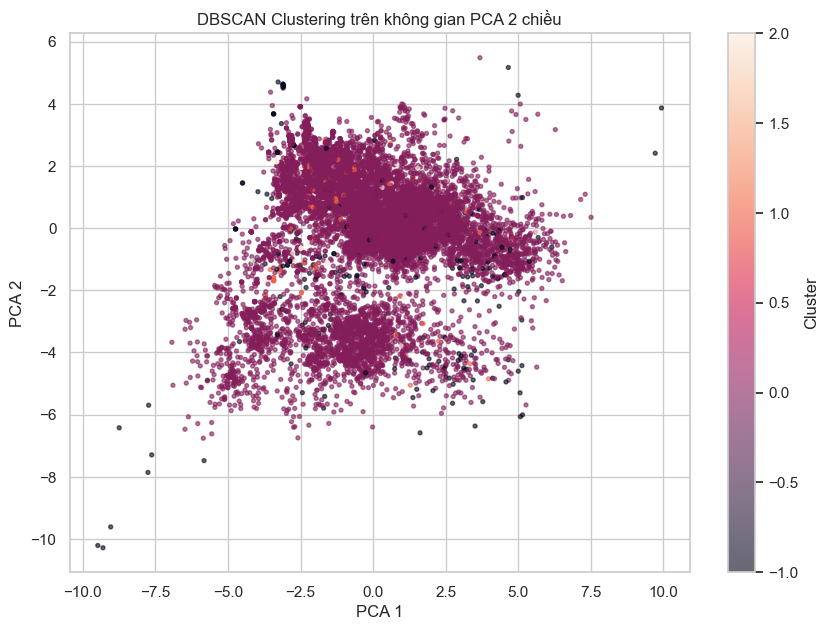

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_sample_pca[:, 0],
    X_sample_pca[:, 1],
    c=sample_labels,
    s=8,
    alpha=0.6
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("DBSCAN Clustering trên không gian PCA 2 chiều")
plt.colorbar(scatter, label="Cluster")

plt.show()

[16.3] Vẽ K-Means để so sánh

K-Means của bạn đã có km_labels, nên không cần fit lại K-Means.

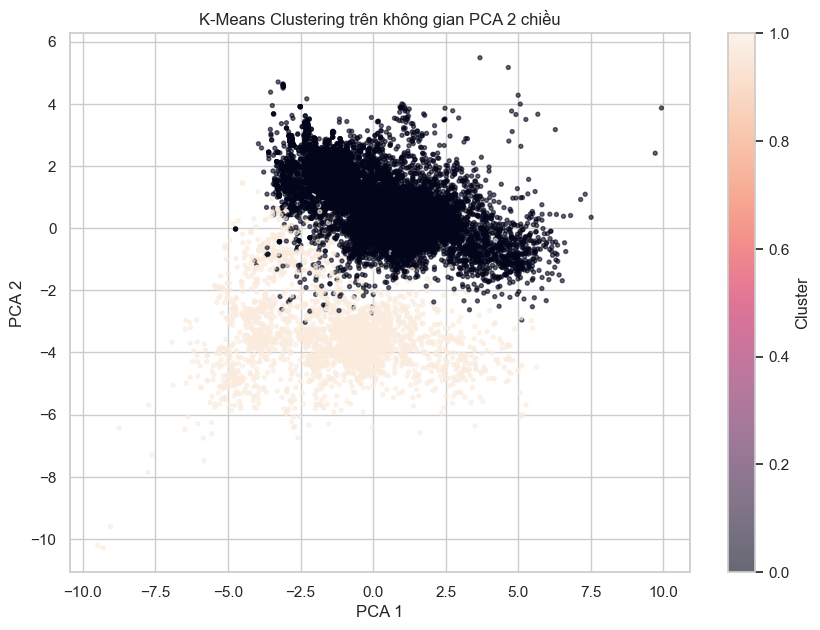

In [34]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_sample_pca[:, 0],
    X_sample_pca[:, 1],
    c=km_labels[sample_idx],
    s=8,
    alpha=0.6
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering trên không gian PCA 2 chiều")
plt.colorbar(scatter, label="Cluster")

plt.show()

[16.4] — biểu đồ so sánh chất lượng 2 thuật toán

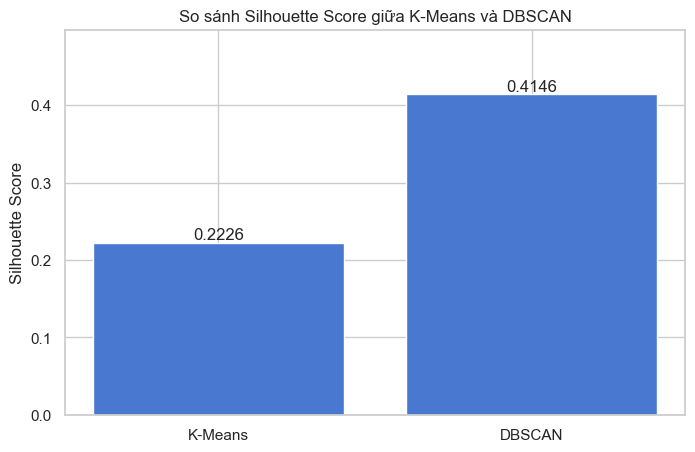

In [36]:
import matplotlib.pyplot as plt

algorithms = ['K-Means', 'DBSCAN']
silhouette_values = [sil_km, 0.414560]

plt.figure(figsize=(8, 5))

bars = plt.bar(algorithms, silhouette_values)

plt.ylabel("Silhouette Score")
plt.title("So sánh Silhouette Score giữa K-Means và DBSCAN")
plt.ylim(0, max(silhouette_values) * 1.2)

for bar, value in zip(bars, silhouette_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()

## [17] Kết luận

Bài toán clustering được thực hiện trên bộ dữ liệu Hotel Booking Demand
sau khi tiền xử lý và chuẩn hóa dữ liệu.

Hai thuật toán K-Means và DBSCAN được áp dụng và so sánh dựa trên
Silhouette Score và Davies-Bouldin Index.

- K-Means với K = 2 đạt Silhouette Score = 0.2226 và
  Davies-Bouldin Index = 2.5680.
- DBSCAN với `eps = 9.0` và `min_samples = 88` đạt
  Silhouette Score = 0.4146 và Davies-Bouldin Index = 0.9486.
- DBSCAN xác định khoảng 1.72% dữ liệu là noise.

Theo hai chỉ số đánh giá, DBSCAN cho chất lượng phân cụm tốt hơn
K-Means trên dữ liệu được sử dụng trong thực nghiệm. Vì vậy,
DBSCAN được lựa chọn làm kết quả clustering cuối cùng.

Tuy nhiên, kết quả DBSCAN có sự mất cân bằng lớn về kích thước cụm:
cluster 0 chiếm 96.73% dữ liệu, trong khi cluster 1 và cluster 2
chỉ chiếm tỷ lệ nhỏ. 